# Dados para Machine Learning: Feature Engineering

In [24]:
# Impoetações
import pandas as pd
import numpy as np
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
df = pd.read_csv("/content/drive/MyDrive/arquivos_tps/datasets/penguins.csv")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female




---



## Exercício 1: Compreensão de Features no Dataset Palmer Penguins

Examine o dataset Palmer Penguins e explique o que são 'features' no contexto deste dataset específico. Discuta como as features influenciam o desempenho de um modelo de Machine Learning.

Nesse dataset Palmer Penguins, as features são as colunas que trazem informações sobre cada pinguim:

**island**: A ilha onde o pinguim vive.

**bill_length_mm**: O comprimento do bico.

**bill_depth_mm**: A profundidade do bico.

**flipper_length_mm**: O comprimento da nadadeira.

**body_mass_g**: A massa corporal (peso).

**sex**: O sexo do pinguim.


As features são a base de aprendizado do modelo. A qualidade e a relevância delas definem se o modelo será bom ou não, se as features tiverem uma relação forte com o que queremos prever (por exemplo, se pinguins da espécie Gentoo forem significativamente maiores que os Adelie), o modelo conseguirá aprender os padrões facilmente e terá alta precisão.

Se usarmos features que não ajudam a diferenciar as classes (como um ID aleatório), elas podem confundir o modelo, gerando "ruído" e piorando o desempenho.



---



## Exercício 2: Escalares, Vetores e Espaços em Machine Learning

Com base nos dados do dataset Palmer Penguins, identifique exemplos de escalares, vetores e explique o conceito de espaços em Machine Learning.

In [2]:
# Exemplo de ESCALAR
escalar = df.loc[0, 'body_mass_g']

# Exemplo de VETOR
vetor = df.loc[0, ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].values

# Mostro os resultados
print(f"Exemplo de Escalar (um único número): {escalar}")
print(f"Exemplo de Vetor (uma lista de números): {vetor}")

Exemplo de Escalar (um único número): 3750.0
Exemplo de Vetor (uma lista de números): [np.float64(39.1) np.float64(18.7) np.float64(181.0) np.float64(3750.0)]


O "Espaço" é "mapa" multidimensional onde o modelo organiza esses vetores para identificar padrões



---



## Exercício 3: Discretização com Bins Fixos no Dataset Palmer Penguins

Utilize a técnica de quantização com bins fixos para discretizar uma variável contínua do dataset Palmer Penguins. Explique a razão pela qual você escolheu essa variável e como a discretização pode afetar a análise.

In [4]:
# Defino os limites dos bins (faixas de peso)
bins = [2700, 3500, 5000, 6300]
labels = ['Leve', 'Médio', 'Pesado']

# Aplico a discretização (pd.cut usa bins fixos)
df['body_mass_cat'] = pd.cut(df['body_mass_g'], bins=bins, labels=labels)

# Visualizar o resultado com a nova coluna
print(df[['body_mass_g', 'body_mass_cat']].head())

   body_mass_g body_mass_cat
0       3750.0         Médio
1       3800.0         Médio
2       3250.0          Leve
3          NaN           NaN
4       3450.0          Leve


Escolhi o peso porque é uma medida que varia continuamente. Em biologia ou estudos ambientais, muitas vezes é mais útil agrupar indivíduos em categorias de tamanho para observar comportamentos ou padrões de sobrevivência, em vez de analisar grama por grama. É muito mais fácil para um ser humano (ou para uma regra de negócio) tomar decisões baseadas em "Pinguins Pesados" do que em valores exatos como "$5123.5\text{g}$".



---



## Exercício 4: Discretização com Bins Variáveis no Dataset Palmer Penguins

Aplique a técnica de quantização com bins variáveis em uma variável contínua do dataset Palmer Penguins. Compare os resultados com a discretização feita no exercício anterior.

In [10]:
df = df.dropna(subset=['body_mass_g']) # Remove nulos para o cálculo

# Aplico bins variáveis (Quantis)
# O 'q=3' divide os dados em 3 partes iguais
df['body_mass_qcut'] = pd.qcut(df['body_mass_g'], q=3, labels=['Leve', 'Médio', 'Pesado'])

# Comparo a distribuição
print("Distribuição com Bins Variáveis (qcut):")
print(df['body_mass_qcut'].value_counts())

Distribuição com Bins Variáveis (qcut):
body_mass_qcut
Leve      117
Pesado    113
Médio     112
Name: count, dtype: int64


**Comparação**:

Bins Fixos (Ex 3): Os intervalos são rígidos (ex: sempre de 1000 em 1000). Pode gerar grupos muito cheios e outros quase vazios.

Bins Variáveis (Ex 4): Os intervalos mudam para garantir equilíbrio. Isso é melhor para o treinamento de modelos, pois garante que cada categoria ("Leve", "Médio", "Pesado") tenha exemplos suficientes para o aprendizado.



---



## Exercício 5: Uso de FunctionTransformer no Dataset Palmer Penguins

Aplique a FunctionTransformer do Scikit-Learn em uma variável do dataset Palmer Penguins. Descreva o processo e explique como essa transformação pode ser benéfica.

In [13]:
df = df.dropna(subset=['body_mass_g'])

# Crio o transformador
# Uso np.log1p que aplica log(1 + x), ideal para evitar erro com valor zero
log_transformer = FunctionTransformer(np.log1p, validate=True)

# Aplicoo a transformação na coluna de massa corporal
# O reshape é necessário se estiver passando apenas uma coluna
body_mass_transformed = log_transformer.transform(df[['body_mass_g']])

# Adiciono ao dataframe para comparação
df['body_mass_log'] = body_mass_transformed
print(df[['body_mass_g', 'body_mass_log']].head())

   body_mass_g  body_mass_log
0       3750.0       8.229778
1       3800.0       8.243019
2       3250.0       8.086718
4       3450.0       8.146419
5       3650.0       8.202756


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but FunctionTransformer was fitted without feature names
  warnings.warn(


**Limpeza**: Primeiro, removo os valores ausentes (NaN), pois funções matemáticas como o logaritmo não podem ser aplicadas a dados nulos.

**Definição da Função**: Escolhi o logaritmo natural (np.log1p).

**Encapsulamento**: Usei o FunctionTransformer para "embrulhar" essa função. O parâmetro validate=True garante que o transformador verifique se os dados são uma matriz de números antes de aplicar a função.

**Aplicação**: O método .transform() executa a conta matemática em todos os registros da coluna selecionada de uma só vez.

A transformação logarítmica ajuda a "achatar" dados que possuem grande variação ou valores muito altos (como o peso em gramas, que vai de 2700 a 6300), aproximando a distribuição de uma curva normal. Isso facilita o aprendizado de algoritmos como Regressão Linear.



---



## Exercício 6: Aplicação de PowerTransformer no Dataset Palmer Penguins

Utilize a PowerTransformer do Scikit-Learn para transformar uma variável do dataset Palmer Penguins. Discuta os benefícios dessa transformação.

In [15]:
# Removo os valores nulos para evitar erros
df = df.dropna(subset=['flipper_length_mm'])

# Instancio o PowerTransforme, por padrão ele usa o método Yeo-Johnson
# que funciona bem tanto para dados positivos quanto negativos
pt = PowerTransformer()

# Aplico a transformação na coluna do comprimento da nadadeira
# Utilizo o reshape para garantir que o formato dos dados esteja correto para o modelo
flipper_transformed = pt.fit_transform(df[['flipper_length_mm']])

# Adiciono o resultado de volta ao meu dataframe para comparar os valores
df['flipper_pt'] = flipper_transformed
print(df[['flipper_length_mm', 'flipper_pt']].head())

   flipper_length_mm  flipper_pt
0              181.0   -1.580741
1              186.0   -1.104687
2              195.0   -0.339985
4              193.0   -0.500529
5              190.0   -0.751119


Ao utilizar o PowerTransformer, eu consigo minimizar a variância e tornar a distribuição dos dados mais simétrica. Isso é extremamente benéfico para muitos algoritmos de Machine Learning, como a Regressão Linear, que parte do pressuposto de que as variáveis seguem uma distribuição normal.



---



## Exercício 7: Normalização Min-Max no Dataset Palmer Penguins

Aplique a normalização Min-Max do Scikit-Learn em uma ou mais variáveis do dataset Palmer Penguins. Explique como essa normalização impacta o modelo de Machine Learning.

In [17]:
df = df.dropna(subset=['bill_length_mm', 'body_mass_g'])

# Instancio o MinMaxScaler para colocar os dados no intervalo entre 0 e 1
scaler = MinMaxScaler()

# Seleciono as colunas que desejo normalizar e aplico a transformação
# Faço isso para que variáveis com números grandes não dominem o modelo
colunas_para_normalizar = ['bill_length_mm', 'body_mass_g']
dados_normalizados = scaler.fit_transform(df[colunas_para_normalizar])

# Crio um novo dataframe com os resultados para visualizar a diferença
df_norm = pd.DataFrame(dados_normalizados, columns=colunas_para_normalizar)
print(df_norm.head())

   bill_length_mm  body_mass_g
0        0.254545     0.291667
1        0.269091     0.305556
2        0.298182     0.152778
3        0.167273     0.208333
4        0.261818     0.263889


Ao aplicar a normalização Min-Max, garanto que todas as características tenham o mesmo peso matemático durante o treinamento. Sem isso, uma variável como a massa corporal (que chega a 6000) teria uma influência muito maior no modelo do que o comprimento do bico (que gira em torno de 40 a 50), simplesmente por causa da magnitude dos números e não pela sua importância real.

Essa transformação é importante para algorimos que dependem de cálculos de distância, como o K-Nearest Neighbors (KNN) ou K-Means



---



## Exercício 8: Normalização com Standard Scaler no Dataset Palmer Penguins

Utilize o StandardScaler do Scikit-Learn para normalizar variáveis do dataset Palmer Penguins. Discuta a diferença entre esta técnica e a normalização Min-Max.

In [19]:
df = df.dropna(subset=['flipper_length_mm', 'body_mass_g'])

# Instancio o StandardScaler para transformar os dados em uma escala de desvios padrão
scaler = StandardScaler()

# Aplico a transformação nas colunas de tamanho da nadadeira e peso
# Isso garante que a distribuição dos dados seja centralizada no zero
colunas = ['flipper_length_mm', 'body_mass_g']
dados_padronizados = scaler.fit_transform(df[colunas])

# Converto de volta para um dataframe para visualizar a média próxima de zero
df_std = pd.DataFrame(dados_padronizados, columns=colunas)
print(df_std.head())

   flipper_length_mm  body_mass_g
0          -1.418347    -0.564142
1          -1.062250    -0.501703
2          -0.421277    -1.188532
3          -0.563715    -0.938776
4          -0.777373    -0.689020


A principal diferença entre essas duas técnicas está na forma como elas lidam com os limites e com a distribuição dos dados:

Enquanto a Min-Max (Ex 7) força todos os dados a ficarem obrigatoriamente entre 0 e 1, a StandardScaler não tem um limite fixo. Os valores geralmente ficam entre -3 e 3, mas podem ser maiores se houver dados muito distantes da média.

A Min-Max é extremamente sensível a valores discrepantes (outliers), pois um único valor muito alto pode fazer com que todos os outros dados fiquem "esmagados" perto do zero. A StandardScaler é um pouco mais robusta, pois utiliza a média e o desvio padrão de todo o conjunto, mantendo a relação de distância entre os pontos de forma mais equilibrada.



---



## Exercício 9: Regularização Norma-L2 no Dataset Palmer Penguins

Implemente um modelo de regressão linear com regularização norma-L2 utilizando o dataset Palmer Penguins.

In [21]:
df = df.dropna(subset=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'])

# Defino as features (X) e o alvo (y), tentando prever o peso com base nas outras medidas
X = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']]
y = df['body_mass_g']

# Divido os dados em conjuntos de treino e teste para validar o desempenho depois
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Aplico a padronização, essencial para que a penalidade da regularização seja justa entre as variáveis
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instancio e treino o modelo Ridge, que aplica a regularização Norma-L2
# O parâmetro alpha controla a força da penalidade
modelo_ridge = Ridge(alpha=1.0)
modelo_ridge.fit(X_train_scaled, y_train)

# Realizo as previsões e calculo o erro para verificar a precisão do modelo
previsoes = modelo_ridge.predict(X_test_scaled)
erro = mean_squared_error(y_test, previsoes)

print(f"Coeficientes do modelo: {modelo_ridge.coef_}")
print(f"Erro Quadrático Médio (MSE): {erro:.2f}")

Coeficientes do modelo: [ 17.22925449  22.55629129 705.5147672 ]
Erro Quadrático Médio (MSE): 122523.37




---



## Exercício 10: Aplicação Complexa de FunctionTransformer com Múltiplas Transformações

Utilize a FunctionTransformer do Scikit-Learn para aplicar múltiplas transformações em sequência a uma variável do dataset Palmer Penguins. Por exemplo, aplique uma transformação logarítmica seguida por uma transformação exponencial inversa. Explique os passos realizados e analise como essas transformações impactam a distribuição da variável transformada.

**Dicas**:

Utilize FunctionTransformer para definir e aplicar cada transformação individualmente.
Analise a distribuição da variável antes e depois das transformações utilizando histogramas e estatísticas descritivas.

Estatísticas Originais:
       body_mass_g
count   342.000000
mean   4201.754386
std     801.954536
min    2700.000000
25%    3550.000000
50%    4050.000000
75%    4750.000000
max    6300.000000

Estatísticas após Transformações:
       body_mass_g
count   342.000000
mean      0.000246
std       0.000046
min       0.000159
25%       0.000210
50%       0.000247
75%       0.000282
max       0.000370


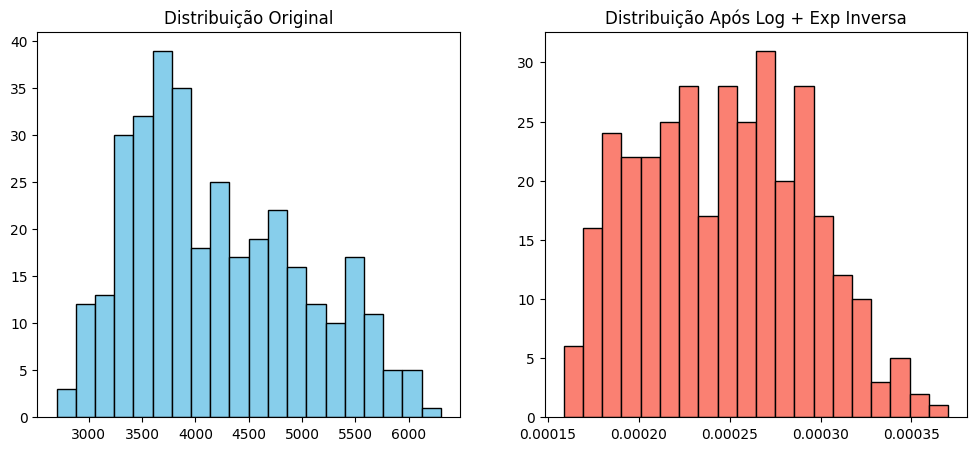

In [23]:
massa_corporal = df[['body_mass_g']].dropna()

# Defino a primeira transformação: Logarítmica
# Ela reduz a magnitude dos valores e comprime a escala
log_trans = FunctionTransformer(np.log1p)

# Defino a segunda transformação: Exponencial Inversa (exp(-x))
# No contexto de um valor logarítmico, isso equivale a calcular 1/(x+1)
inv_exp_trans = FunctionTransformer(lambda x: np.exp(-x))

# Aplico as transformações em sequência
massa_log = log_trans.transform(massa_corporal)
massa_final = inv_exp_trans.transform(massa_log)

# Comparo as estatísticas descritivas
print("Estatísticas Originais:")
print(massa_corporal.describe())
print("\nEstatísticas após Transformações:")
print(pd.DataFrame(massa_final).describe())

# Visualizo a mudança na distribuição através de histogramas
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(massa_corporal['body_mass_g'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribuição Original')

plt.subplot(1, 2, 2)
plt.hist(massa_final, bins=20, color='salmon', edgecolor='black')
plt.title('Distribuição Após Log + Exp Inversa')
plt.savefig('distribuicao_transformada.png')


**Primeiro passo (Logaritmo)**: A aplicação do logaritmo comprimiu os valores da massa corporal, que estavam na casa dos milhares, para uma escala muito menor (entre 7 e 9). Isso reduz o impacto de valores muito altos e ajuda a linearizar relações.

**Segundo passo (Exponencial Inversa)**: Ao aplicar $e^{-x}$ sobre o resultado do logaritmo, transformei os dados em valores extremamente pequenos (entre $0.0001$ e $0.0003$). Matematicamente, como apliquei o exponencial inverso sobre um logaritmo, o resultado final é equivalente ao inverso dos dados originais ($1/x$).



**Impacto na Distribuição:** A distribuição original da massa corporal dos pinguins apresentava uma leve assimetria à direita. Após as transformações, a ordem dos dados foi invertida (pinguins que eram os mais pesados agora possuem os menores valores transformados). Além disso, a escala foi drasticamente reduzida, o que pode ser útil em modelos matemáticos específicos que exigem entradas em intervalos muito pequenos ou que precisam lidar com taxas de variação inversa.Estatisticamente, a média caiu de $4201.75$ para aproximadamente $0.0002$, mostrando como a engenharia de atributos pode mudar completamente a representação numérica de uma mesma característica biológica.



---
## Exercício 11: Comparação de Transformações com PowerTransformer

Aplique a PowerTransformer do Scikit-Learn a uma variável do dataset Palmer Penguins. Em seguida, aplique uma transformação alternativa, como a normalização z-score (StandardScaler). Compare as distribuições resultantes das variáveis transformadas usando gráficos e estatísticas descritivas. Discuta as diferenças observadas e as situações em que cada técnica pode ser mais apropriada.

Dicas:

Utilize PowerTransformer e StandardScaler para aplicar as transformações.
Compare os resultados utilizando histogramas, box plots e estatísticas como média e desvio padrão.



       PowerTransformer  StandardScaler
count      3.420000e+02    3.420000e+02
mean      -1.163462e-15    1.662088e-16
std        1.001465e+00    1.001465e+00
min       -2.266609e+00   -2.168526e+00
25%       -8.547723e-01   -8.615697e-01
50%        1.199007e-01    9.686524e-02
75%        8.459776e-01    8.397670e-01
max        2.727199e+00    2.875868e+00


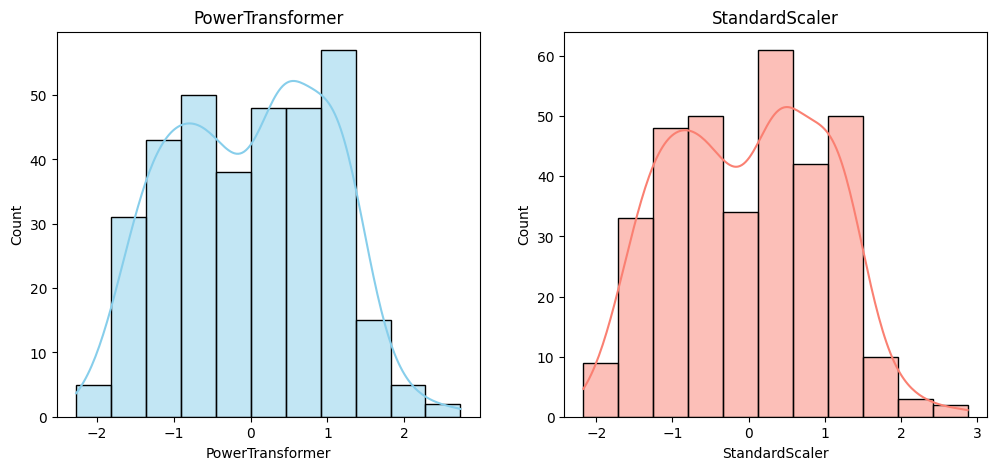

In [25]:
dados = df[['bill_length_mm']].dropna()

# Instancio e aplico o PowerTransformer (Yeo-Johnson)
# Esta técnica foca em tornar a distribuição mais Gaussiana (normal)
pt = PowerTransformer()
dados_pt = pt.fit_transform(dados)

# Instancio e aplico o StandardScaler (Z-score)
# Esta técnica apenas centraliza a média em 0 e ajusta o desvio padrão para 1
ss = StandardScaler()
dados_ss = ss.fit_transform(dados)

# Crio um DataFrame comparativo para análise estatística
comparacao = pd.DataFrame({
    'PowerTransformer': dados_pt.flatten(),
    'StandardScaler': dados_ss.flatten()
})

# Exibo as estatísticas descritivas para comparar média e desvio padrão
print(comparacao.describe())

# Gero histogramas para visualizar as mudanças na forma da distribuição
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(comparacao['PowerTransformer'], kde=True, ax=ax1, color='skyblue').set_title('PowerTransformer')
sns.histplot(comparacao['StandardScaler'], kde=True, ax=ax2, color='salmon').set_title('StandardScaler')
plt.savefig('comparacao_distribuicoes.png')

**Estatísticas**: Ambas as técnicas tem um resuldo da média muito próxima de 0 e um desvio padrão de 1. Mas os valores mínimos e máximos diferem. O StandardScaler mantém a proporção exata das distâncias originais, enquanto o PowerTransformer distorce levemente essas distâncias para forçar a simetria.

**Forma da Distribuição**: O StandardScaler apenas desloca e reescala o histograma original; se os dados eram assimétricos, eles continuarão assimétricos. Já o PowerTransformer atua na "curvatura" dos dados, reduzindo a assimetria (skewness) para que o gráfico se assemelhe mais a uma curva de sino perfeita.



---



**StandardScaler**: É a minha escolha padrão quando os dados já possuem uma distribuição próxima da normal ou quando o algoritmo não exige normalidade, mas é sensível à escala.

**PowerTransformer**: Eu prefiro esta técnica quando os dados são muito "tortos" (alta assimetria) e pretendo utilizar modelos que assumem premissas de normalidade (como a Regressão Linear ou modelos Gaussianos). Ela é mais agressiva, pois altera a estrutura original dos dados para satisfazer requisitos estatísticos específicos.



---

## Exercício 12: Normalização Min-Max Individualmente

Aplique a normalização Min-Max do Scikit-Learn a uma variável contínua do dataset Palmer Penguins. Visualize os dados normalizados e compare com os dados originais. Explique como a normalização Min-Max influencia a visualização dos dados e a comparação entre diferentes variáveis.

Dicas:

Utilize MinMaxScaler para normalizar a variável selecionada.
Visualize os dados antes e depois da normalização utilizando gráficos como pair plots ou heatmaps.

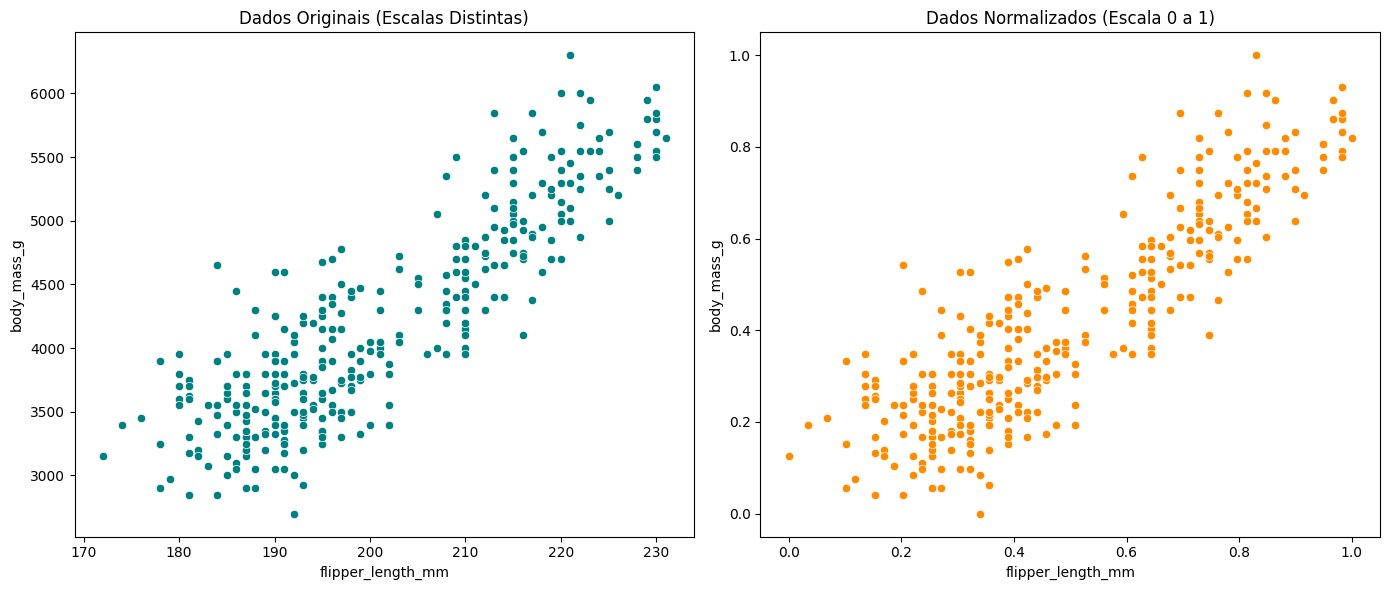

Estatísticas após Normalização Min-Max:
     flipper_length_mm  body_mass_g
min                0.0          0.0
max                1.0          1.0


In [26]:
colunas = ['flipper_length_mm', 'body_mass_g']
dados = df[colunas].dropna()

# Instancio o MinMaxScaler para transformar os dados para o intervalo [0, 1]
scaler = MinMaxScaler()
dados_normalizados = scaler.fit_transform(dados)

# Crio um DataFrame para comparar as escalas antes e depois
df_normalizado = pd.DataFrame(dados_normalizados, columns=colunas)

# Preparo a visualização comparativa usando gráficos de dispersão
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico com dados originais (escalas diferentes)
sns.scatterplot(data=dados, x='flipper_length_mm', y='body_mass_g', ax=ax1, color='teal')
ax1.set_title('Dados Originais (Escalas Distintas)')

# Gráfico com dados normalizados (mesma escala 0-1)
sns.scatterplot(data=df_normalizado, x='flipper_length_mm', y='body_mass_g', ax=ax2, color='darkorange')
ax2.set_title('Dados Normalizados (Escala 0 a 1)')

plt.tight_layout()
plt.show()

# Exibo as estatísticas para validar o novo intervalo
print("Estatísticas após Normalização Min-Max:")
print(df_normalizado.describe().loc[['min', 'max']])